# ANNNI model

We consider the one-dimensional axial next-nearest-neighbor Ising (ANNNI) model
$$
H
=\frac{J_1}{4} \sum_{i} Z_i Z_{i+1}
+\frac{J_2}{4} \sum_{i} Z_i Z_{i+2}
-\frac{G}{2} \sum_{i} X_i\,.
$$

### Parameter setting:

- **Task:** Ground state preparation
- **Figure:** Energy dynamics
- **System size:** $L=4$ sites
- **Inverse temperature:**  $\beta=1$
- **Gaussian filter width:** $\sigma=2$
- **Coupling strengths:** $\Gamma/\sigma \in \{1, 0.5, 0.25, 0.1, 0.05, 0.01\}$
- **Bath frequency sampling:** $\omega$ is uniformly sampled from [0,5]
- **System operator sampling:** spin operators

In [1]:
import quimb as qu
import numpy as np
import random
from numpy import linalg as LA
from scipy.linalg import expm
from scipy.sparse.linalg import expm as sparse_expm
from operator import add
from autoray import do, dag
from scipy.sparse import coo_matrix, bmat, csr_matrix
from scipy.integrate import odeint, complex_ode
import matplotlib as mpl # noqa
import matplotlib.pyplot as plt # noqa
from tqdm import tqdm
from quimb.tensor.tensor_1d_compress import *

from hamiltonians import h_annni,jw_spin_ops
from channels import _expm_from_eigh,_sym_herm,f_gaussian,trace_out_last_qubit,suzuki_trotter_vbasis

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning

op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

In [ ]:
# --- fix all random seeds for reproducibility ---
np.random.seed(50)
random.seed(50)

N=8 #number of sites in the physical model
sigma = 4 #width of the Gaussian pulse
Ss = 5 * sigma #simulation time in one iteration
dTime = 0.1 #time step size in one iteration
Nstep = 1000 #number of iterations
dims = [2] * (N+1) #total system+bath dimension
BB = 5 #maximum bath frequency
alpha_list = np.array([1]) * (sigma**0.5)

#ANNNI model Hamiltonian
Hamsys = h_annni(L=N, J1=-0.5, J2=-0.15, g=0.1, h=0.0, cyclic=True)
# Hamsys = Hamsys.tocoo()
Hamsys = Hamsys.toarray()
Hamsys_original = Hamsys.copy()
eigenvalues, eigenvectors = LA.eigh(Hamsys)
ground_energy = eigenvalues[0]
phi_ini = eigenvectors[:, -1]
print("Ground state energy of the system Hamiltonian:", ground_energy)

#build system+bath eigendecomp once
eigvec_bath_0 = np.array([1,0])
eigvec_bath_1 = np.array([0,1])
Q_se = np.array([np.kron(eigenvectors[:, k], eigvec_bath)
        for k in range(len(eigenvalues))
        for eigvec_bath in (eigvec_bath_0, eigvec_bath_1)])
Q_se = Q_se.T

Hamsys = np.kron(Hamsys, np.eye(2))
jump_op_array = jw_spin_ops(N) #sample from spin operators

#simulation loop
energy = np.zeros((Nstep+1,len(alpha_list)))
energy[0,:] = np.real(phi_ini.conj() @ Hamsys_original @ phi_ini)
phi_list = phi_ini.copy()
count_n = 0

for i in tqdm(range(Nstep)):

    omega = random.uniform(0, BB)
    w_se =  np.array([eigenvalues[k]+eig_bath for k in range(len(eigenvectors))
            for eig_bath in (-omega/2, omega/2)])
    Hambath = -omega * qu.spin_operator('z', **op_kws)
    Hambath = Hambath.toarray()
    Hambath = qu.kron(qu.eye(2**(N), **op_kws), Hambath)
    Hambath = Hambath.toarray()
    phi_bath = np.array([1,0])

    k = random.randint(0, N-1)
    # for spin model
    A = random.choice(jump_op_array)
    B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)
    
    sign_random = (-1)**(random.randint(0,1))
    interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
    interact += interact.conj().T
    wv, Qv = np.linalg.eigh(interact.toarray())

    for idx, alpha in enumerate(alpha_list):
        
        U0_half  = _expm_from_eigh(Q_se, w_se, factor=(-1j * dTime / 2.0))

        U = np.eye(2**(N+1))
        phi_temp = np.kron(phi_list, phi_bath)

        # precompute the pulse values for this i
        nsub  = 2*round(Ss/dTime) + 1
        tgrid = (np.arange(nsub) * dTime) - Ss
        fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

        phi_list = trace_out_last_qubit(suzuki_trotter_vbasis(phi_temp, fvals, alpha, dTime, Qv, wv, U0_half))
        
        energy[i+1,idx] = np.real(phi_list.conj().T @ Hamsys_original @ phi_list)
        
        if np.abs(energy[i+1, idx] - ground_energy) < 0.01:
            count_n += 1
            if count_n >= 10:
                print(f"Reached ground state energy stably after step {i+1-count_n} with energy diff 10e-2")
                energy[i+1:,idx] = np.real(phi_list.conj().T @ Hamsys_original @ phi_list)
                break
            else:
                count_n = 0


2614323189.py:38: RuntimeWarning: divide by zero encountered in matmul
2614323189.py:38: RuntimeWarning: overflow encountered in matmul
2614323189.py:38: RuntimeWarning: invalid value encountered in matmul


Ground state energy of the system Hamiltonian: -2.8583053109397274


  0%|          | 0/1000 [00:00<?, ?it/s]channels.py:27: RuntimeWarning: divide by zero encountered in matmul
channels.py:27: RuntimeWarning: overflow encountered in matmul
channels.py:27: RuntimeWarning: invalid value encountered in matmul
channels.py:246: RuntimeWarning: divide by zero encountered in matmul
channels.py:246: RuntimeWarning: overflow encountered in matmul
channels.py:246: RuntimeWarning: invalid value encountered in matmul
channels.py:247: RuntimeWarning: divide by zero encountered in matmul
channels.py:247: RuntimeWarning: overflow encountered in matmul
channels.py:247: RuntimeWarning: invalid value encountered in matmul
channels.py:248: RuntimeWarning: divide by zero encountered in matmul
channels.py:248: RuntimeWarning: overflow encountered in matmul
channels.py:248: RuntimeWarning: invalid value encountered in matmul
channels.py:251: RuntimeWarning: divide by zero encountered in matmul
channels.py:251: RuntimeWarning: overflow encountered in matmul
channels.py:251: 

In [4]:
save_data = {"energy": energy}
np.savez("data/ground_result_ANNNI_8.npz", **save_data)

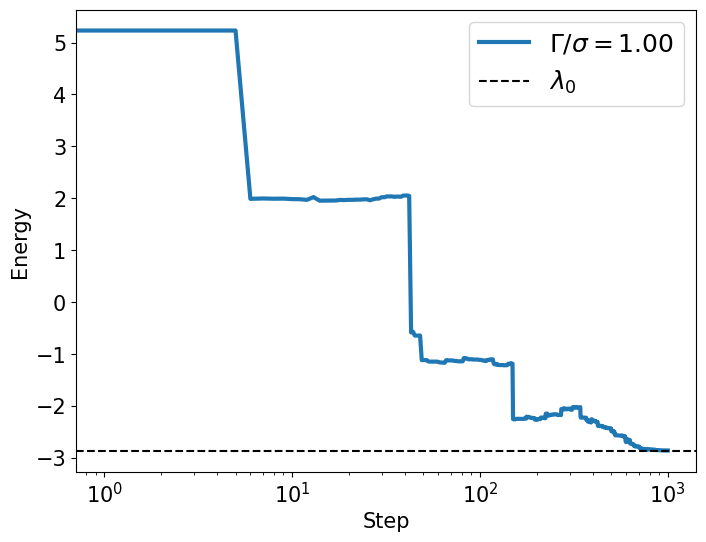

In [5]:
plt.figure(figsize=(8,6))
linestyles = ["-", "--", "-.", ":", "-", "--"]
for idx in range(len(alpha_list)):
    ratio = alpha_list[idx] / np.sqrt(sigma)
    plt.plot(energy[0:Nstep+1,idx], linewidth=3, label=fr'$\Gamma/\sigma = {ratio:.2f}$', linestyle=linestyles[idx])

plt.axhline(y=ground_energy, color='k', linestyle='--', label=r'$\lambda_0$')
plt.xlabel(r'Step', fontsize=15)
plt.ylabel(r'Energy', fontsize=15)
plt.legend(fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale('log', base=10)
# plt.yscale('log', base=10)
plt.savefig("figures/ANNNI_energy_8.pdf", bbox_inches="tight", dpi=300)
plt.show()